# Inspect one RGB–Thermal aligned sample

This notebook reads a published aligned sample, converts the radiometric TIFF to Celsius using its XMP calibration, and displays the thermal image, aligned RGB, overlay, and 80 °C mask. Set `DATASET_ID` and `ALIGNED_ID` below to inspect another aligned sample.

In [1]:
from pathlib import Path
import csv
import json
import re
import matplotlib.pyplot as plt
import numpy as np
import tifffile
from PIL import Image

repo_root = Path.cwd()
if not (repo_root / 'data').exists():
    repo_root = Path('..').resolve()

DATASET_ID = '0002'
ALIGNED_ID = '000189_20260226_030803'  # None selects the middle aligned sample
sample_dir = repo_root / 'examples' / 'sample_aligned'
dataset_dir = repo_root / 'data' / DATASET_ID
if dataset_dir.is_dir():
    with (dataset_dir / 'processed' / 'manifest.csv').open(newline='', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))
    row = next(item for item in rows if item['aligned_id'] == ALIGNED_ID) if ALIGNED_ID else rows[len(rows) // 2]
    aligned_dir = dataset_dir / Path(row['thermal_tiff_path']).parent
else:
    row = json.loads((sample_dir / 'manifest_row.json').read_text(encoding='utf-8'))
    aligned_dir = sample_dir
row

{'aligned_id': '000189_20260226_030803',
 'status': 'exported',
 'tiff_name': '20260226_030803.tiff',
 'tiff_time_iso': '2026-02-26 03:08:03',
 'video_time_s': '475.5',
 'video_time': '00:07:55.500',
 'video_frame_index': '14265',
 'thermal_source_path': 'raw/thermal/20260226_030803.tiff',
 'thermal_tiff_path': 'processed/aligned/000189_20260226_030803/thermal.tiff',
 'thermal_png_path': 'processed/aligned/000189_20260226_030803/thermal.png',
 'video_png_path': 'processed/aligned/000189_20260226_030803/video.png',
 'overlay_png_path': 'processed/aligned/000189_20260226_030803/overlay.png',
 'visual_score': '0.3634047210216522',
 'thermal_edge_density': '0.250244140625',
 'video_edge_density': '0.21817626953125',
 'anchor_segment': 'primary',
 'anchor_requested_video_time_s': '292.0',
 'anchor_requested_video_time': '00:04:52',
 'anchor_selected_video_time_s': '292.5',
 'anchor_selected_video_time': '00:04:52.500',
 'anchor_center_tiff': '20260226_030500.tiff',
 'mask_80c_path': 'proces

In [2]:
def xmp_number(page, name, default):
    tag = page.tags.get('XMP')
    if tag is None:
        return default
    text = tag.value.decode('utf-8', errors='replace') if isinstance(tag.value, bytes) else str(tag.value)
    match = re.search(rf'<(?:[A-Za-z_][\w.-]*:)?{name}>\s*([^<]+?)\s*</', text)
    return float(match.group(1)) if match else default

with tifffile.TiffFile(aligned_dir / 'thermal.tiff') as tif:
    page = tif.pages[0]
    dn = np.asarray(page.asarray(), dtype=np.float32)
    gain = xmp_number(page, 'TlinearGain', 0.04)
temperature_c = dn * gain - 273.15
thermal_rgb = np.asarray(Image.open(aligned_dir / 'thermal.png').convert('RGB'))
video_rgb = np.asarray(Image.open(aligned_dir / 'video.png').convert('RGB'))
overlay_rgb = np.asarray(Image.open(aligned_dir / 'overlay.png').convert('RGB'))
mask = np.asarray(Image.open(aligned_dir / 'mask_80c.png'))
print(f"aligned={row['aligned_id']}  video_time={row.get('video_time', '')}  frame={row.get('video_frame_index', '')}")
print(f"DN range={dn.min():.0f}..{dn.max():.0f}; temperature={temperature_c.min():.2f}..{temperature_c.max():.2f} °C; mask positive={int(mask.sum())}")

aligned=000189_20260226_030803  video_time=00:07:55.500  frame=14265
DN range=7210..11568; temperature=15.25..189.57 °C; mask positive=28056


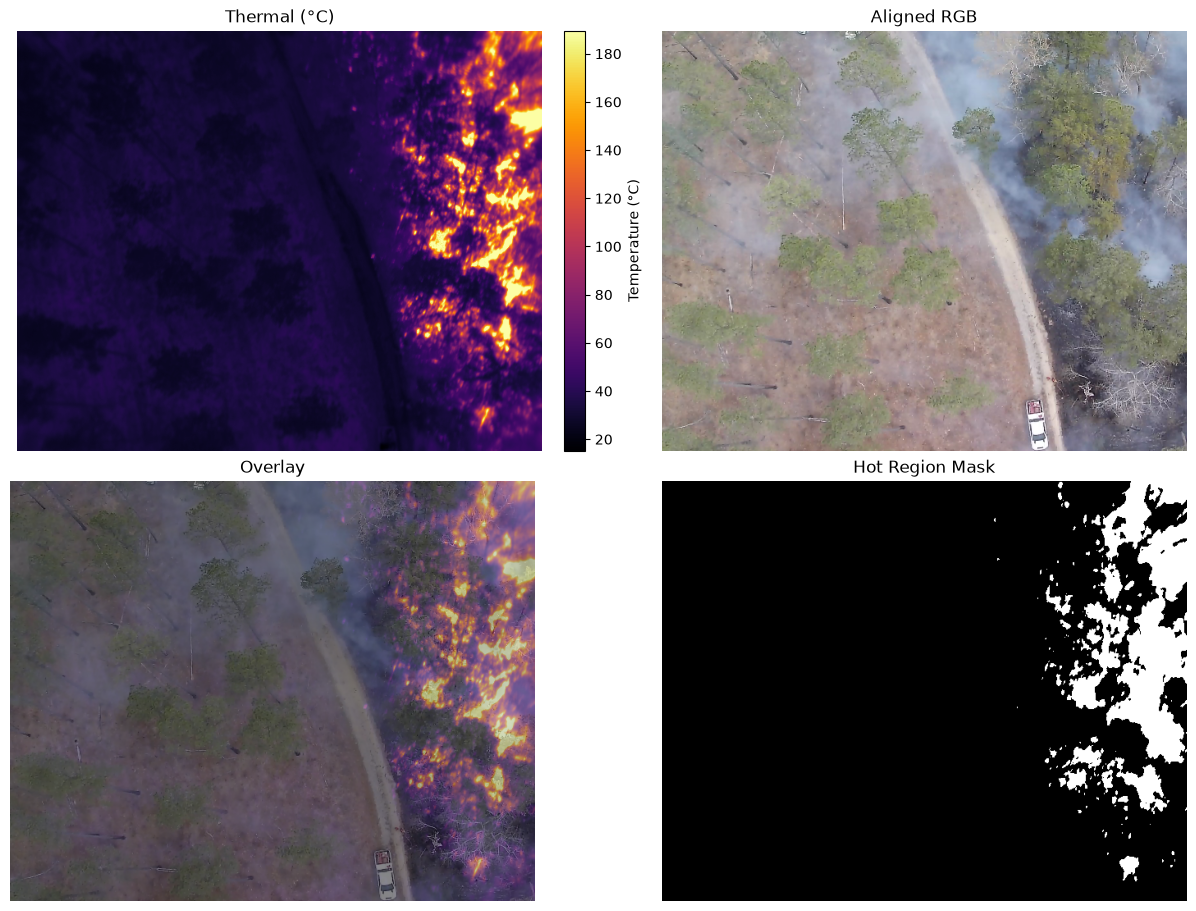

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
thermal_plot = axes[0, 0].imshow(temperature_c, cmap='inferno')
axes[0, 0].set_title('Thermal (°C)')
axes[0, 0].axis('off')
colorbar = fig.colorbar(thermal_plot, ax=axes[0, 0], fraction=0.046, pad=0.04)
colorbar.set_label('Temperature (°C)')
axes[0, 1].imshow(video_rgb); axes[0, 1].set_title('Aligned RGB'); axes[0, 1].axis('off')
axes[1, 0].imshow(overlay_rgb); axes[1, 0].set_title('Overlay'); axes[1, 0].axis('off')
axes[1, 1].imshow(mask, cmap='gray', vmin=0, vmax=1); axes[1, 1].set_title('Hot Region Mask'); axes[1, 1].axis('off')
plt.show()